# FSRS4Anki Optimizer Test version

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-spaced-repetition/fsrs4anki/blob/test/fsrs4anki_optimizer_test.ipynb)

↑ Click the above button to open the optimizer on Google Colab.

> If you can't see the button and are located in the Chinese Mainland, please use a proxy or VPN.

Upload your **Anki Deck Package (.apkg)** file or **Anki Collection Package (.colpkg)** file on the `Left sidebar -> Files`, drag and drop your file in the current directory (not the `sample_data` directory). 

No need to include media. Need to include scheduling information. 

> If you use the latest version of Anki, please check the box `Support older Anki versions (slower/larger files)` when you export.

You can export it via `File -> Export...` or `Ctrl + E` in the main window of Anki.

Then replace the `filename` with yours in the next code cell. And set the `timezone` and `next_day_starts_at` which can be found in your preferences of Anki.

After that, just run all (`Runtime -> Run all` or `Ctrl + F9`) and wait for minutes. You can see the optimal parameters in section **2.3 Result**. Copy them, replace the parameters in `fsrs4anki_scheduler.js`, and paste them into the custom scheduling of your deck options (require Anki version >= 2.1.55).

**NOTE**: The default output is generated from my review logs. If you find the output is the same as mine, maybe your notebook hasn't run there.

**Contribute to SRS Research**: If you want to share your data with me, please fill this form: https://forms.gle/KaojsBbhMCytaA7h8

In [1]:
# Here are some settings that you need to replace before running this optimizer.

filename = "collection-2022-09-18@13-21-58.colpkg"
# If you upload deck file, replace it with your deck filename. E.g., ALL__Learning.apkg
# If you upload collection file, replace it with your colpkg filename. E.g., collection-2022-09-18@13-21-58.colpkg

# Replace it with your timezone. I'm in China, so I use Asia/Shanghai.
# You can find your timezone here: https://gist.github.com/heyalexej/8bf688fd67d7199be4a1682b3eec7568
timezone = "Asia/Shanghai"

# Replace it with your Anki's setting in Preferences -> Scheduling.
next_day_starts_at = 4

# Replace it if you don't want the optimizer to use the review logs before a specific date.
revlog_start_date = "2006-10-05"  # YYYY-MM-DD

# Set it to True if you don't want the optimizer to use the review logs from suspended cards.
filter_out_suspended_cards = False

# Red: 1, Orange: 2, Green: 3, Blue: 4, Pink: 5, Turquoise: 6, Purple: 7
# Set it to [1, 2] if you don't want the optimizer to use the review logs from cards with red or orange flag.
filter_out_flags = []

## 1 Build dataset

### 1.1 Extract Anki collection & deck file

In [2]:
import zipfile
import sqlite3
import time
import pandas as pd
import numpy as np
import os
import math
from typing import List, Optional
from datetime import timedelta, datetime
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from torch import nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import StratifiedGroupKFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
from itertools import accumulate
from tqdm.auto import tqdm
import warnings

tqdm.pandas()
warnings.filterwarnings("ignore", category=UserWarning)

New = 0
Learning = 1
Review = 2
Relearning = 3


"""Step 1"""
# Extract the collection file or deck file to get the .anki21 database.
with zipfile.ZipFile(f"{filename}", "r") as zip_ref:
    zip_ref.extractall("./")
    tqdm.write("Deck file extracted successfully!")
if os.path.isfile("collection.anki21b"):
    os.remove("collection.anki21b")
    raise Exception(
        "Please export the file with `support older Anki versions` if you use the latest version of Anki."
    )
elif os.path.isfile("collection.anki21"):
    con = sqlite3.connect("collection.anki21")
elif os.path.isfile("collection.anki2"):
    con = sqlite3.connect("collection.anki2")
else:
    raise Exception("Collection not exist!")
cur = con.cursor()


def flags2str(flags: List[int]) -> str:
    return f"({','.join(map(str, flags))})"


res = cur.execute(
    f"""
SELECT *
FROM revlog
WHERE cid IN (
    SELECT id
    FROM cards
    WHERE queue != 0
    {"AND queue != -1" if filter_out_suspended_cards else ""}
    {"AND flags NOT IN %s" % flags2str(filter_out_flags) if len(filter_out_flags) > 0 else ""}
)
"""
)
revlog = res.fetchall()
if len(revlog) == 0:
    raise Exception("No review log found!")
df = pd.DataFrame(revlog)
df.columns = [
    "review_time",
    "card_id",
    "usn",
    "review_rating",
    "ivl",
    "last_ivl",
    "factor",
    "review_duration",
    "review_state",
]
df = df[
    (df["card_id"] <= time.time() * 1000) & (df["review_time"] <= time.time() * 1000)
].copy()
df_set_due_date = df[(df["review_state"] == 4) & (df["ivl"] > 0)]
df.drop(df_set_due_date.index, inplace=True)
df.sort_values(by=["card_id", "review_time"], inplace=True, ignore_index=True)
df["is_learn_start"] = (df["review_state"] == 0) & (df["review_state"].shift() != 0)
df["sequence_group"] = df["is_learn_start"].cumsum()
last_learn_start = df[df["is_learn_start"]].groupby("card_id")["sequence_group"].last()
df["last_learn_start"] = df["card_id"].map(last_learn_start).fillna(0).astype(int)
df["mask"] = df["last_learn_start"] <= df["sequence_group"]
df = df[df["mask"] == True].copy()
df = df[(df["review_state"] != 4)].copy()
df = df[(df["review_state"] != 3) | (df["factor"] != 0)].copy()
df["review_state"] = df["review_state"] + 1
df.loc[df["is_learn_start"], "review_state"] = New
df.drop(
    columns=[
        "is_learn_start",
        "sequence_group",
        "last_learn_start",
        "mask",
        "usn",
        "ivl",
        "last_ivl",
        "factor",
    ],
    inplace=True,
)
df.to_csv("revlog.csv", index=False)
tqdm.write("revlog.csv saved.")

Deck file extracted successfully!
revlog.csv saved.


### 1.2 Create time-series feature & analysis

The following code cell will extract the review logs from your Anki collection and preprocess them to a trainset which is saved in [./revlog_history.tsv](./revlog_history.tsv).

The time-series features are important in optimizing the model's parameters. For more detail, please see my paper: https://www.maimemo.com/paper/

Then it will generate a concise analysis for your review logs. 

- The `r_history` is the history of ratings on each review. `3,3,3,1` means that you press `Good, Good, Good, Again`. It only contains the first rating for each card on the review date, i.e., when you press `Again` in review and  `Good` in relearning steps 10min later, only `Again` will be recorded.
- The `avg_interval` is the actual average interval after you rate your cards as the `r_history`. It could be longer than the interval given by Anki's built-in scheduler because you reviewed some overdue cards.
- The `avg_retention` is the average retention after you press as the `r_history`. `Again` counts as failed recall, and `Hard, Good and Easy` count as successful recall. Retention is the percentage of your successful recall.
- The `stability` is the estimated memory state variable, which is an approximate interval that leads to 90% retention.
- The `factor` is `stability / previous stability`.
- The `group_cnt` is the number of review logs that have the same `r_history`.

In [3]:
"""Step 2"""
df = pd.read_csv("./revlog.csv")
df.sort_values(by=["card_id", "review_time"], inplace=True, ignore_index=True)
new_card_revlog = df[
    (df["review_state"] == New) & (df["review_rating"].isin([1, 2, 3, 4]))
]
first_rating_prob = np.zeros(4)
first_rating_prob[new_card_revlog["review_rating"].value_counts().index - 1] = (
    new_card_revlog["review_rating"].value_counts()
    / new_card_revlog["review_rating"].count()
)
recall_card_revlog = df[
    (df["review_state"] == Review) & (df["review_rating"].isin([2, 3, 4]))
]
review_rating_prob = np.zeros(3)
review_rating_prob[recall_card_revlog["review_rating"].value_counts().index - 2] = (
    recall_card_revlog["review_rating"].value_counts()
    / recall_card_revlog["review_rating"].count()
)
df["review_state"] = df["review_state"].map(lambda x: x if x != New else Learning)
recall_costs = np.zeros(3)
recall_costs_df = recall_card_revlog.groupby(by="review_rating")[
    "review_duration"
].mean()
recall_costs[recall_costs_df.index - 2] = recall_costs_df / 1000
state_sequence = np.array(df["review_state"])
duration_sequence = np.array(df["review_duration"])
learn_cost = round(
    df[df["review_state"] == Learning]["review_duration"].sum()
    / len(df["card_id"].unique())
    / 1000,
    1,
)
df["review_date"] = pd.to_datetime(df["review_time"] // 1000, unit="s")
df["review_date"] = df["review_date"].dt.tz_localize("UTC").dt.tz_convert(timezone)
df.drop(df[df["review_date"].dt.year < 2006].index, inplace=True)
df["real_days"] = df["review_date"] - timedelta(hours=int(next_day_starts_at))
df["real_days"] = pd.DatetimeIndex(
    df["real_days"].dt.floor("D", ambiguous="infer", nonexistent="shift_forward")
).to_julian_date()
df.drop_duplicates(["card_id", "real_days"], keep="first", inplace=True)
df["delta_t"] = df.real_days.diff()
df["delta_t"].fillna(0, inplace=True)
df.dropna(inplace=True)
df["i"] = df.groupby("card_id").cumcount() + 1
df.loc[df["i"] == 1, "delta_t"] = 0
df = df.groupby("card_id").filter(
    lambda group: group["review_state"].iloc[0] == Learning
)
if df.empty:
    raise ValueError("Training data is inadequate.")
df["prev_review_state"] = (
    df.groupby("card_id")["review_state"].shift(1).fillna(Learning).astype(int)
)
df["helper"] = (
    (df["review_state"] == Learning)
    & ((df["prev_review_state"] == Review) | (df["prev_review_state"] == Relearning))
    & (df["i"] > 1)
).astype(int)
df["helper"] = df.groupby("card_id")["helper"].cumsum()
df = df[df["helper"] == 0]
del df["prev_review_state"]
del df["helper"]


def cum_concat(x):
    return list(accumulate(x))


t_history = df.groupby("card_id", group_keys=False)["delta_t"].apply(
    lambda x: cum_concat([[int(i)] for i in x])
)
df["t_history"] = [
    ",".join(map(str, item[:-1])) for sublist in t_history for item in sublist
]
r_history = df.groupby("card_id", group_keys=False)["review_rating"].apply(
    lambda x: cum_concat([[i] for i in x])
)
df["r_history"] = [
    ",".join(map(str, item[:-1])) for sublist in r_history for item in sublist
]
df = df.groupby("card_id").filter(
    lambda group: group["review_time"].min()
    > time.mktime(datetime.strptime(revlog_start_date, "%Y-%m-%d").timetuple()) * 1000
)
df = df[(df["review_rating"] != 0) & (df["r_history"].str.contains("0") == 0)].copy()
df["y"] = df["review_rating"].map(lambda x: {1: 0, 2: 1, 3: 1, 4: 1}[x])


def remove_outliers(group: pd.DataFrame) -> pd.DataFrame:
    # threshold = np.mean(group['delta_t']) * 1.5
    # threshold = group['delta_t'].quantile(0.95)
    # Q1 = group['delta_t'].quantile(0.25)
    # Q3 = group['delta_t'].quantile(0.75)
    # IQR = Q3 - Q1
    # threshold = Q3 + 1.5 * IQR
    # group = group[group['delta_t'] <= threshold]
    grouped_group = (
        group.groupby(by=["r_history", "delta_t"], group_keys=False)
        .agg({"y": ["mean", "count"]})
        .reset_index()
    )
    sort_index = grouped_group.sort_values(
        by=[("y", "count"), "delta_t"], ascending=[True, False]
    ).index
    total = sum(grouped_group[("y", "count")])
    has_been_removed = 0
    for i in sort_index:
        count = grouped_group.loc[i, ("y", "count")]
        if has_been_removed + count >= total * 0.05:
            break
        has_been_removed += count
    group = group[
        group["delta_t"].isin(
            grouped_group[grouped_group[("y", "count")] >= count]["delta_t"]
        )
    ]
    return group


df[df["i"] == 2] = (
    df[df["i"] == 2]
    .groupby(by=["r_history", "t_history"], as_index=False, group_keys=False)
    .apply(remove_outliers)
)
df.dropna(inplace=True)


def remove_non_continuous_rows(group):
    discontinuity = group["i"].diff().fillna(1).ne(1)
    if not discontinuity.any():
        return group
    else:
        first_non_continuous_index = discontinuity.idxmax()
        return group.loc[: first_non_continuous_index - 1]


df = df.groupby("card_id", as_index=False, group_keys=False).progress_apply(
    remove_non_continuous_rows
)
df["review_time"] = df["review_time"].astype(int)
df["review_rating"] = df["review_rating"].astype(int)
df["review_duration"] = df["review_duration"].astype(int)
df["review_state"] = df["review_state"].astype(int)
df["delta_t"] = df["delta_t"].astype(int)
df["i"] = df["i"].astype(int)
df["t_history"] = df["t_history"].astype(str)
df["r_history"] = df["r_history"].astype(str)
df["y"] = df["y"].astype(int)
df.to_csv("revlog_history.tsv", sep="\t", index=False)
tqdm.write("Trainset saved.")
S0_dataset = df[df["i"] == 2]
S0_dataset_group = (
    S0_dataset.groupby(by=["r_history", "delta_t"], group_keys=False)
    .agg({"y": ["mean", "count"]})
    .reset_index()
)
S0_dataset_group.to_csv("stability_for_pretrain.tsv", sep="\t", index=None)
df["retention"] = df.groupby(by=["r_history", "delta_t"], group_keys=False)[
    "y"
].transform("mean")
df["total_cnt"] = df.groupby(by=["r_history", "delta_t"], group_keys=False)[
    "review_time"
].transform("count")
tqdm.write("Retention calculated.")
df.drop(
    columns=[
        "review_time",
        "card_id",
        "review_duration",
        "review_state",
        "review_date",
        "real_days",
        "review_rating",
        "t_history",
        "y",
    ],
    inplace=True,
)
df.drop_duplicates(inplace=True)
df["retention"] = df["retention"].map(lambda x: max(min(0.99, x), 0.01))


def cal_stability(group: pd.DataFrame) -> pd.DataFrame:
    group_cnt = sum(group.groupby("delta_t").first()["total_cnt"])
    if group_cnt < 10:
        return pd.DataFrame()
    group["group_cnt"] = group_cnt
    if group["i"].values[0] > 1:
        r_ivl_cnt = sum(
            group["delta_t"]
            * group["retention"].map(np.log)
            * pow(group["total_cnt"], 2)
        )
        ivl_ivl_cnt = sum(
            group["delta_t"].map(lambda x: x**2) * pow(group["total_cnt"], 2)
        )
        group["stability"] = round(np.log(0.9) / (r_ivl_cnt / ivl_ivl_cnt), 1)
    else:
        group["stability"] = 0.0
    group["avg_retention"] = round(
        sum(group["retention"] * pow(group["total_cnt"], 2))
        / sum(pow(group["total_cnt"], 2)),
        3,
    )
    group["avg_interval"] = round(
        sum(group["delta_t"] * pow(group["total_cnt"], 2))
        / sum(pow(group["total_cnt"], 2)),
        1,
    )
    del group["total_cnt"]
    del group["retention"]
    del group["delta_t"]
    return group


df = df.groupby(by=["r_history"], group_keys=False).progress_apply(cal_stability)
tqdm.write("Stability calculated.")
df.reset_index(drop=True, inplace=True)
df.drop_duplicates(inplace=True)
df.sort_values(by=["r_history"], inplace=True, ignore_index=True)
if df.shape[0] > 0:
    for idx in tqdm(df.index, desc="analysis"):
        item = df.loc[idx]
        index = df[
            (df["i"] == item["i"] + 1)
            & (df["r_history"].str.startswith(item["r_history"]))
        ].index
        df.loc[index, "last_stability"] = item["stability"]
    df["factor"] = round(df["stability"] / df["last_stability"], 2)
    df = df[(df["i"] >= 2) & (df["group_cnt"] >= 100)].copy()
    df["last_recall"] = df["r_history"].map(lambda x: x[-1])
    df = df[
        df.groupby(["i", "r_history"], group_keys=False)["group_cnt"].transform(max)
        == df["group_cnt"]
    ]
    df.to_csv("./stability_for_analysis.tsv", sep="\t", index=None)
    tqdm.write("Analysis saved!")
    caption = "1:again, 2:hard, 3:good, 4:easy\n"
    analysis = df[df["r_history"].str.contains(r"^[1-4][^124]*$", regex=True)][
        [
            "r_history",
            "avg_interval",
            "avg_retention",
            "stability",
            "factor",
            "group_cnt",
        ]
    ].to_string(index=False)
    caption + analysis

  0%|          | 0/9793 [00:00<?, ?it/s]

Trainset saved.
Retention calculated.


  0%|          | 0/25764 [00:00<?, ?it/s]

Stability calculated.


analysis:   0%|          | 0/481 [00:00<?, ?it/s]

Analysis saved!


## 2 Optimize parameter

### 2.1 Define & Train the model

FSRS is a time-series model for predicting memory states.

The [./revlog_history.tsv](./revlog_history.tsv) generated before will be used for training the FSRS model.

In [4]:
verbose = False

init_w = [
    0.4,
    0.9,
    2.3,
    10.9,
    4.93,
    0.94,
    0.86,
    0.01,
    1.49,
    0.14,
    0.94,
    2.18,
    0.05,
    0.34,
    1.26,
    0.29,
    2.61,
]


def power_forgetting_curve(t, s):
    return (1 + t / (9 * s)) ** -1


dataset = pd.read_csv(
    "./revlog_history.tsv",
    sep="\t",
    index_col=None,
    dtype={"r_history": str, "t_history": str},
)

dataset = dataset[
    (dataset["i"] > 1)
    & (dataset["delta_t"] > 0)
    & (dataset["t_history"].str.count(",0") == 0)
]
if dataset.empty:
    raise ValueError("Training data is inadequate.")
rating_stability = {}
rating_count = {}
average_recall = dataset["y"].mean()
plots = []
r_s0_default = {"1": 0.4, "2": 0.9, "3": 2.3, "4": 10.9}
for first_rating in ("1", "2", "3", "4"):
    group = S0_dataset_group[
        S0_dataset_group["r_history"] == first_rating
    ]
    if group.empty:
        tqdm.write(
            f"Not enough data for first rating {first_rating}. Expected at least 1, got 0."
        )
        continue
    delta_t = group["delta_t"]
    recall = (group["y"]["mean"] * group["y"]["count"] + average_recall * 1) / (
        group["y"]["count"] + 1
    )
    count = group["y"]["count"]
    total_count = sum(count)
    init_s0 = r_s0_default[first_rating]

    def loss(stability):
        y_pred = power_forgetting_curve(delta_t, stability)
        logloss = sum(
            -(recall * np.log(y_pred) + (1 - recall) * np.log(1 - y_pred))
            * count
            / total_count
        )
        l1 = np.abs(stability - init_s0) / total_count / 16
        return logloss + l1
    res = minimize(
        loss,
        x0=init_s0,
        bounds=((0.1, 365),),
        options={"maxiter": int(np.sqrt(total_count))},
    )
    params = res.x
    stability = params[0]
    rating_stability[int(first_rating)] = stability
    rating_count[int(first_rating)] = total_count
    predict_recall = power_forgetting_curve(delta_t, *params)
    rmse = mean_squared_error(
        recall, predict_recall, sample_weight=count, squared=False
    )
    if verbose:
        fig = plt.figure()
        ax = fig.gca()
        ax.plot(delta_t, recall, label="Exact")
        ax.plot(
            np.linspace(0, 30),
            power_forgetting_curve(np.linspace(0, 30), *params),
            label=f"Weighted fit (RMSE: {rmse:.4f})",
        )
        count_percent = np.array([x / total_count for x in count])
        ax.scatter(delta_t, recall, s=count_percent * 1000, alpha=0.5)
        ax.legend(loc="upper right", fancybox=True, shadow=False)
        ax.grid(True)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Interval")
        ax.set_ylabel("Recall")
        ax.set_title(
            f"Forgetting curve for first rating {first_rating} (n={total_count}, s={stability:.2f})"
        )
        plots.append(fig)
        tqdm.write(str(rating_stability))
for small_rating, big_rating in (
    (1, 2),
    (2, 3),
    (3, 4),
    (1, 3),
    (2, 4),
    (1, 4),
):
    if small_rating in rating_stability and big_rating in rating_stability:
        if rating_stability[small_rating] > rating_stability[big_rating]:
            if rating_count[small_rating] > rating_count[big_rating]:
                rating_stability[big_rating] = rating_stability[small_rating]
            else:
                rating_stability[small_rating] = rating_stability[big_rating]
w1 = 3 / 5
w2 = 3 / 5
if len(rating_stability) == 0:
    raise Exception("Not enough data for pretraining!")
elif len(rating_stability) == 1:
    rating = list(rating_stability.keys())[0]
    factor = rating_stability[rating] / r_s0_default[str(rating)]
    init_s0 = list(map(lambda x: x * factor, r_s0_default.values()))
elif len(rating_stability) == 2:
    if 1 not in rating_stability and 2 not in rating_stability:
        rating_stability[2] = np.power(
            rating_stability[3], 1 / (1 - w2)
        ) * np.power(rating_stability[4], 1 - 1 / (1 - w2))
        rating_stability[1] = np.power(rating_stability[2], 1 / w1) * np.power(
            rating_stability[3], 1 - 1 / w1
        )
    elif 1 not in rating_stability and 3 not in rating_stability:
        rating_stability[3] = np.power(rating_stability[2], 1 - w2) * np.power(
            rating_stability[4], w2
        )
        rating_stability[1] = np.power(rating_stability[2], 1 / w1) * np.power(
            rating_stability[3], 1 - 1 / w1
        )
    elif 1 not in rating_stability and 4 not in rating_stability:
        rating_stability[4] = np.power(
            rating_stability[2], 1 - 1 / w2
        ) * np.power(rating_stability[3], 1 / w2)
        rating_stability[1] = np.power(rating_stability[2], 1 / w1) * np.power(
            rating_stability[3], 1 - 1 / w1
        )
    elif 2 not in rating_stability and 3 not in rating_stability:
        rating_stability[2] = np.power(
            rating_stability[1], w1 / (w1 + w2 - w1 * w2)
        ) * np.power(rating_stability[4], 1 - w1 / (w1 + w2 - w1 * w2))
        rating_stability[3] = np.power(
            rating_stability[1], 1 - w2 / (w1 + w2 - w1 * w2)
        ) * np.power(rating_stability[4], w2 / (w1 + w2 - w1 * w2))
    elif 2 not in rating_stability and 4 not in rating_stability:
        rating_stability[2] = np.power(rating_stability[1], w1) * np.power(
            rating_stability[3], 1 - w1
        )
        rating_stability[4] = np.power(
            rating_stability[2], 1 - 1 / w2
        ) * np.power(rating_stability[3], 1 / w2)
    elif 3 not in rating_stability and 4 not in rating_stability:
        rating_stability[3] = np.power(
            rating_stability[1], 1 - 1 / (1 - w1)
        ) * np.power(rating_stability[2], 1 / (1 - w1))
        rating_stability[4] = np.power(
            rating_stability[2], 1 - 1 / w2
        ) * np.power(rating_stability[3], 1 / w2)
    init_s0 = [
        item[1] for item in sorted(rating_stability.items(), key=lambda x: x[0])
    ]
elif len(rating_stability) == 3:
    if 1 not in rating_stability:
        rating_stability[1] = np.power(rating_stability[2], 1 / w1) * np.power(
            rating_stability[3], 1 - 1 / w1
        )
    elif 2 not in rating_stability:
        rating_stability[2] = np.power(rating_stability[1], w1) * np.power(
            rating_stability[3], 1 - w1
        )
    elif 3 not in rating_stability:
        rating_stability[3] = np.power(rating_stability[2], 1 - w2) * np.power(
            rating_stability[4], w2
        )
    elif 4 not in rating_stability:
        rating_stability[4] = np.power(
            rating_stability[2], 1 - 1 / w2
        ) * np.power(rating_stability[3], 1 / w2)
    init_s0 = [
        item[1] for item in sorted(rating_stability.items(), key=lambda x: x[0])
    ]
elif len(rating_stability) == 4:
    init_s0 = [
        item[1] for item in sorted(rating_stability.items(), key=lambda x: x[0])
    ]
init_w[0:4] = init_s0
tqdm.write(f"Pretrain finished!")


class FSRS(nn.Module):
    def __init__(self, w: List[float]):
        super(FSRS, self).__init__()
        self.w = nn.Parameter(torch.tensor(w, dtype=torch.float32))

    def stability_after_success(
        self, state: Tensor, new_d: Tensor, r: Tensor, rating: Tensor
    ) -> Tensor:
        hard_penalty = torch.where(rating == 2, self.w[15], 1)
        easy_bonus = torch.where(rating == 4, self.w[16], 1)
        new_s = state[:, 0] * (
            1
            + torch.exp(self.w[8])
            * (11 - new_d)
            * torch.pow(state[:, 0], -self.w[9])
            * (torch.exp((1 - r) * self.w[10]) - 1)
            * hard_penalty
            * easy_bonus
        )
        return new_s

    def stability_after_failure(
        self, state: Tensor, new_d: Tensor, r: Tensor
    ) -> Tensor:
        new_s = (
            self.w[11]
            * torch.pow(new_d, -self.w[12])
            * (torch.pow(state[:, 0] + 1, self.w[13]) - 1)
            * torch.exp((1 - r) * self.w[14])
        )
        return new_s

    def step(self, X: Tensor, state: Tensor) -> Tensor:
        """
        :param X: shape[batch_size, 2], X[:,0] is elapsed time, X[:,1] is rating
        :param state: shape[batch_size, 2], state[:,0] is stability, state[:,1] is difficulty
        :return state:
        """
        if torch.equal(state, torch.zeros_like(state)):
            keys = torch.tensor([1, 2, 3, 4])
            keys = keys.view(1, -1).expand(X[:, 1].long().size(0), -1)
            index = (X[:, 1].long().unsqueeze(1) ==
                     keys).nonzero(as_tuple=True)
            # first learn, init memory states
            new_s = torch.ones_like(state[:, 0])
            new_s[index[0]] = self.w[index[1]]
            new_d = self.w[4] - self.w[5] * (X[:, 1] - 3)
            new_d = new_d.clamp(1, 10)
        else:
            r = power_forgetting_curve(X[:, 0], state[:, 0])
            new_d = state[:, 1] - self.w[6] * (X[:, 1] - 3)
            new_d = self.mean_reversion(self.w[4], new_d)
            new_d = new_d.clamp(1, 10)
            condition = X[:, 1] > 1
            new_s = torch.where(
                condition,
                self.stability_after_success(state, new_d, r, X[:, 1]),
                self.stability_after_failure(state, new_d, r),
            )
        new_s = new_s.clamp(0.1, 36500)
        return torch.stack([new_s, new_d], dim=1)

    def forward(self, inputs: Tensor, state: Optional[Tensor] = None) -> Tensor:
        """
        :param inputs: shape[seq_len, batch_size, 2]
        """
        if state is None:
            state = torch.zeros((inputs.shape[1], 2))
        outputs = []
        for X in inputs:
            state = self.step(X, state)
            outputs.append(state)
        return torch.stack(outputs), state

    def mean_reversion(self, init: Tensor, current: Tensor) -> Tensor:
        return self.w[7] * init + (1 - self.w[7]) * current


class WeightClipper:
    def __init__(self, frequency: int = 1):
        self.frequency = frequency

    def __call__(self, module):
        if hasattr(module, "w"):
            w = module.w.data
            w[4] = w[4].clamp(1, 10)
            w[5] = w[5].clamp(0.1, 5)
            w[6] = w[6].clamp(0.1, 5)
            w[7] = w[7].clamp(0, 0.5)
            w[8] = w[8].clamp(0, 3)
            w[9] = w[9].clamp(0.1, 0.8)
            w[10] = w[10].clamp(0.01, 2.5)
            w[11] = w[11].clamp(0.5, 5)
            w[12] = w[12].clamp(0.01, 0.2)
            w[13] = w[13].clamp(0.01, 0.9)
            w[14] = w[14].clamp(0.01, 2)
            w[15] = w[15].clamp(0, 1)
            w[16] = w[16].clamp(1, 10)
            module.w.data = w


def lineToTensor(line: str) -> Tensor:
    ivl = line[0].split(",")
    response = line[1].split(",")
    tensor = torch.zeros(len(response), 2)
    for li, response in enumerate(response):
        tensor[li][0] = int(ivl[li])
        tensor[li][1] = int(response)
    return tensor


class RevlogDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        if dataframe.empty:
            raise ValueError("Training data is inadequate.")
        padded = pad_sequence(
            dataframe["tensor"].to_list(), batch_first=True, padding_value=0
        )
        self.x_train = padded.int()
        self.t_train = torch.tensor(
            dataframe["delta_t"].values, dtype=torch.int)
        self.y_train = torch.tensor(dataframe["y"].values, dtype=torch.float)
        self.seq_len = torch.tensor(
            dataframe["tensor"].map(len).values, dtype=torch.long
        )

    def __getitem__(self, idx):
        return (
            self.x_train[idx],
            self.t_train[idx],
            self.y_train[idx],
            self.seq_len[idx],
        )

    def __len__(self):
        return len(self.y_train)


class RevlogSampler(Sampler[List[int]]):
    def __init__(self, data_source: RevlogDataset, batch_size: int):
        self.data_source = data_source
        self.batch_size = batch_size
        lengths = np.array(data_source.seq_len)
        indices = np.argsort(lengths)
        full_batches, remainder = divmod(indices.size, self.batch_size)
        if full_batches > 0:
            if remainder == 0:
                self.batch_indices = np.split(indices, full_batches)
            else:
                self.batch_indices = np.split(
                    indices[:-remainder], full_batches)
        else:
            self.batch_indices = []
        if remainder > 0:
            self.batch_indices.append(indices[-remainder:])
        self.batch_nums = len(self.batch_indices)
        # seed = int(torch.empty((), dtype=torch.int64).random_().item())
        seed = 2023
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

    def __iter__(self):
        yield from (
            self.batch_indices[idx]
            for idx in torch.randperm(
                self.batch_nums, generator=self.generator
            ).tolist()
        )

    def __len__(self):
        return len(self.data_source)


def collate_fn(batch):
    sequences, delta_ts, labels, seq_lens = zip(*batch)
    sequences_packed = pack_padded_sequence(
        torch.stack(sequences, dim=1),
        lengths=torch.stack(seq_lens),
        batch_first=False,
        enforce_sorted=False,
    )
    sequences_padded, length = pad_packed_sequence(
        sequences_packed, batch_first=False)
    sequences_padded = torch.as_tensor(sequences_padded)
    seq_lens = torch.as_tensor(length)
    delta_ts = torch.as_tensor(delta_ts)
    labels = torch.as_tensor(labels)
    return sequences_padded, delta_ts, labels, seq_lens


class Trainer:
    def __init__(
        self,
        train_set: pd.DataFrame,
        test_set: pd.DataFrame,
        init_w: List[float],
        n_epoch: int = 1,
        lr: float = 1e-2,
        batch_size: int = 256,
    ) -> None:
        self.model = FSRS(init_w)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.clipper = WeightClipper()
        self.batch_size = batch_size
        self.build_dataset(train_set, test_set)
        self.n_epoch = n_epoch
        self.batch_nums = self.next_train_data_loader.batch_sampler.batch_nums
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=self.batch_nums * n_epoch
        )
        self.avg_train_losses = []
        self.avg_eval_losses = []
        self.loss_fn = nn.BCELoss(reduction="none")

    def build_dataset(self, train_set: pd.DataFrame, test_set: pd.DataFrame):
        pre_train_set = train_set[train_set["i"] == 2]
        self.pre_train_set = RevlogDataset(pre_train_set)
        sampler = RevlogSampler(self.pre_train_set, batch_size=self.batch_size)
        self.pre_train_data_loader = DataLoader(
            self.pre_train_set, batch_sampler=sampler, collate_fn=collate_fn
        )

        next_train_set = train_set[train_set["i"] > 2]
        self.next_train_set = RevlogDataset(next_train_set)
        sampler = RevlogSampler(self.next_train_set,
                                batch_size=self.batch_size)
        self.next_train_data_loader = DataLoader(
            self.next_train_set, batch_sampler=sampler, collate_fn=collate_fn
        )

        self.train_set = RevlogDataset(train_set)
        sampler = RevlogSampler(self.train_set, batch_size=self.batch_size)
        self.train_data_loader = DataLoader(
            self.train_set, batch_sampler=sampler, collate_fn=collate_fn
        )

        self.test_set = RevlogDataset(test_set)
        sampler = RevlogSampler(self.test_set, batch_size=self.batch_size)
        self.test_data_loader = DataLoader(
            self.test_set, batch_sampler=sampler, collate_fn=collate_fn
        )
        tqdm.write("dataset built")

    def train(self, verbose: bool = True):
        best_loss = np.inf
        epoch_len = len(self.next_train_data_loader)
        pbar = tqdm(desc="train", colour="red", total=epoch_len * self.n_epoch)
        print_len = max(self.batch_nums * self.n_epoch // 10, 1)
        for k in range(self.n_epoch):
            weighted_loss, w = self.eval()
            if weighted_loss < best_loss:
                best_loss = weighted_loss
                best_w = w

            for i, batch in enumerate(self.next_train_data_loader):
                self.model.train()
                self.optimizer.zero_grad()
                sequences, delta_ts, labels, seq_lens = batch
                real_batch_size = seq_lens.shape[0]
                outputs, _ = self.model(sequences)
                stabilities = outputs[seq_lens - 1,
                                      torch.arange(real_batch_size), 0]
                retentions = power_forgetting_curve(delta_ts, stabilities)
                loss = self.loss_fn(retentions, labels).sum()
                loss.backward()
                for param in self.model.parameters():
                    param.grad[:4] = torch.zeros(4)
                self.optimizer.step()
                self.scheduler.step()
                self.model.apply(self.clipper)
                pbar.update(real_batch_size)

                if verbose and (k * self.batch_nums + i + 1) % print_len == 0:
                    tqdm.write(
                        f"iteration: {k * epoch_len + (i + 1) * self.batch_size}"
                    )
                    for name, param in self.model.named_parameters():
                        tqdm.write(
                            f"{name}: {list(map(lambda x: round(float(x), 4),param))}"
                        )
        pbar.close()

        weighted_loss, w = self.eval()
        if weighted_loss < best_loss:
            best_loss = weighted_loss
            best_w = w

        return best_w

    def eval(self):
        self.model.eval()
        with torch.no_grad():
            sequences, delta_ts, labels, seq_lens = (
                self.train_set.x_train,
                self.train_set.t_train,
                self.train_set.y_train,
                self.train_set.seq_len,
            )
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens - 1,
                                  torch.arange(real_batch_size), 0]
            retentions = power_forgetting_curve(delta_ts, stabilities)
            tran_loss = self.loss_fn(retentions, labels).mean()
            self.avg_train_losses.append(tran_loss)

            sequences, delta_ts, labels, seq_lens = (
                self.test_set.x_train,
                self.test_set.t_train,
                self.test_set.y_train,
                self.test_set.seq_len,
            )
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens - 1,
                                  torch.arange(real_batch_size), 0]
            retentions = power_forgetting_curve(delta_ts, stabilities)
            test_loss = self.loss_fn(retentions, labels).mean()
            self.avg_eval_losses.append(test_loss)

            w = list(
                map(
                    lambda x: round(float(x), 4),
                    dict(self.model.named_parameters())["w"].data,
                )
            )

            weighted_loss = (
                tran_loss * len(self.train_set) +
                test_loss * len(self.test_set)
            ) / (len(self.train_set) + len(self.test_set))

            return weighted_loss, w

    def plot(self):
        fig = plt.figure()
        ax = fig.gca()
        ax.plot(self.avg_train_losses, label="train")
        ax.plot(self.avg_eval_losses, label="test")
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.legend()
        return fig


class Collection:
    def __init__(self, w: List[float]) -> None:
        self.model = FSRS(w)
        self.model.eval()

    def predict(self, t_history: str, r_history: str):
        with torch.no_grad():
            line_tensor = lineToTensor(
                list(zip([t_history], [r_history]))[0]
            ).unsqueeze(1)
            output_t = self.model(line_tensor)
            return output_t[-1][0]

    def batch_predict(self, dataset):
        fast_dataset = RevlogDataset(dataset)
        with torch.no_grad():
            outputs, _ = self.model(fast_dataset.x_train.transpose(0, 1))
            stabilities, difficulties = outputs[
                fast_dataset.seq_len - 1, torch.arange(len(fast_dataset))
            ].transpose(0, 1)
            return stabilities.tolist(), difficulties.tolist()


def evaluate():
    my_collection = Collection(init_w)
    stabilities, difficulties = my_collection.batch_predict(dataset)
    dataset["stability"] = stabilities
    dataset["difficulty"] = difficulties
    dataset["p"] = power_forgetting_curve(
        dataset["delta_t"], dataset["stability"]
    )
    dataset["log_loss"] = dataset.apply(
        lambda row: -np.log(row["p"]) if row["y"] == 1 else -
        np.log(1 - row["p"]),
        axis=1,
    )
    loss_before = dataset["log_loss"].mean()
    my_collection = Collection(w)
    stabilities, difficulties = my_collection.batch_predict(dataset)
    dataset["stability"] = stabilities
    dataset["difficulty"] = difficulties
    dataset["p"] = power_forgetting_curve(
        dataset["delta_t"], dataset["stability"]
    )
    dataset["log_loss"] = dataset.apply(
        lambda row: -np.log(row["p"]) if row["y"] == 1 else -
        np.log(1 - row["p"]),
        axis=1,
    )
    loss_after = dataset["log_loss"].mean()
    tmp = dataset.copy()
    tmp["stability"] = tmp["stability"].map(lambda x: round(x, 2))
    tmp["difficulty"] = tmp["difficulty"].map(lambda x: round(x, 2))
    tmp["p"] = tmp["p"].map(lambda x: round(x, 2))
    tmp["log_loss"] = tmp["log_loss"].map(lambda x: round(x, 2))
    tmp.rename(columns={"p": "retrievability"}, inplace=True)
    tmp[
        [
            "review_time",
            "card_id",
            "review_date",
            "r_history",
            "t_history",
            "delta_t",
            "review_rating",
            "stability",
            "difficulty",
            "retrievability",
            "log_loss",
        ]
    ].to_csv("./evaluation.tsv", sep="\t", index=False)
    del tmp
    return loss_before, loss_after

# code from https://github.com/papousek/duolingo-halflife-regression/blob/master/evaluation.py


def load_brier(predictions, real, bins=20):
    counts = np.zeros(bins)
    correct = np.zeros(bins)
    prediction = np.zeros(bins)

    def get_bin(x, bins=bins):
        return np.floor(np.exp(np.log(bins + 1) * x)) - 1

    for p, r in zip(predictions, real):
        bin = int(min(get_bin(p), bins - 1))
        counts[bin] += 1
        correct[bin] += r
        prediction[bin] += p

    np.seterr(invalid="ignore")
    prediction_means = prediction / counts
    correct_means = correct / counts
    size = len(predictions)
    answer_mean = sum(correct) / size
    return {
        "reliability": sum(counts * (correct_means - prediction_means) ** 2) / size,
        "resolution": sum(counts * (correct_means - answer_mean) ** 2) / size,
        "uncertainty": answer_mean * (1 - answer_mean),
        "detail": {
            "bin_count": bins,
            "bin_counts": counts,
            "bin_prediction_means": prediction_means,
            "bin_correct_means": correct_means,
        },
    }


def plot_brier(predictions, real, bins=20, ax=None, title=None):
    brier = load_brier(predictions, real, bins=bins)
    bin_prediction_means = brier["detail"]["bin_prediction_means"]
    bin_correct_means = brier["detail"]["bin_correct_means"]
    bin_counts = brier["detail"]["bin_counts"]
    mask = bin_counts > 0
    r2 = r2_score(
        bin_correct_means[mask],
        bin_prediction_means[mask],
        sample_weight=bin_counts[mask],
    )
    rmse = mean_squared_error(
        bin_correct_means[mask],
        bin_prediction_means[mask],
        sample_weight=bin_counts[mask],
        squared=False,
    )
    mae = mean_absolute_error(
        bin_correct_means[mask],
        bin_prediction_means[mask],
        sample_weight=bin_counts[mask],
    )
    tqdm.write(f"R-squared: {r2:.4f}")
    tqdm.write(f"RMSE: {rmse:.4f}")
    tqdm.write(f"MAE: {mae:.4f}")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True)
    try:
        fit_wls = sm.WLS(
            bin_correct_means[mask],
            sm.add_constant(bin_prediction_means[mask]),
            weights=bin_counts[mask],
        ).fit()
        tqdm.write(str(fit_wls.params))
        y_regression = [fit_wls.params[0] +
                        fit_wls.params[1] * x for x in [0, 1]]
        ax.plot(
            [0, 1],
            y_regression,
            label="Weighted Least Squares Regression",
            color="green",
        )
    except:
        pass
    ax.plot(
        bin_prediction_means[mask],
        bin_correct_means[mask],
        label="Actual Calibration",
        color="#1f77b4",
    )
    ax.plot((0, 1), (0, 1), label="Perfect Calibration", color="#ff7f0e")
    bin_count = brier["detail"]["bin_count"]
    counts = np.array(bin_counts)
    bins = np.log((np.arange(bin_count)) + 1) / np.log(bin_count + 1)
    widths = np.diff(bins)
    widths = np.append(widths, 1 - bins[-1])
    ax.legend(loc="upper center")
    ax.set_xlabel("Predicted R")
    ax.set_ylabel("Actual R")
    ax2 = ax.twinx()
    ax2.set_ylabel("Number of reviews")
    ax2.bar(
        bins,
        counts,
        width=widths,
        ec="k",
        linewidth=0,
        alpha=0.5,
        label="Number of reviews",
        align="edge",
    )
    ax2.legend(loc="lower center")
    if title:
        ax.set_title(title)
    metrics = {"R-squared": r2, "RMSE": rmse, "MAE": mae}
    return metrics


def calibration_helper(calibration_data, key, bin_func, semilogx):
    fig = plt.figure()
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twinx()
    lns = []

    def to_percent(temp, position):
        return "%1.0f" % (100 * temp) + "%"
    calibration_data["bin"] = calibration_data[key].map(bin_func)
    calibration_group = calibration_data.groupby("bin").count()
    lns1 = ax1.bar(
        x=calibration_group.index,
        height=calibration_group["y"],
        width=calibration_group.index / 5.5 if key == "stability" else 0.8,
        ec="k",
        lw=0.2,
        label="Number of predictions",
        alpha=0.5,
    )
    ax1.set_ylabel("Number of predictions")
    ax1.set_xlabel(key.title())
    if semilogx:
        ax1.semilogx()
    lns.append(lns1)
    calibration_group = calibration_data.groupby(by="bin").agg("mean")
    lns2 = ax2.plot(calibration_group["y"], label="Actual retention")
    lns3 = ax2.plot(calibration_group["p"], label="Predicted retention")
    ax2.set_ylabel("Retention")
    ax2.set_ylim(0, 1)
    lns.append(lns2[0])
    lns.append(lns3[0])
    labs = [l.get_label() for l in lns]
    ax2.legend(lns, labs, loc="lower right")
    ax2.grid(linestyle="--")
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(to_percent))
    ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))
    return fig


"""Step 4"""

lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 5
batch_size: int = 512
verbose: bool = False

dataset["tensor"] = dataset.progress_apply(
    lambda x: lineToTensor(list(zip([x["t_history"]], [x["r_history"]]))[0]),
    axis=1,
)
dataset["group"] = dataset["r_history"] + dataset["t_history"]
tqdm.write("Tensorized!")
w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(
        dataset, dataset["i"], dataset["group"]
    ):
        tqdm.write(f"TRAIN: {len(train_index)} TEST: {len(test_index)}")
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(
            train_set,
            test_set,
            init_w,
            n_epoch=n_epoch,
            lr=lr,
            batch_size=batch_size,
        )
        w.append(trainer.train(verbose=verbose))
        if verbose:
            plots.append(trainer.plot())
else:
    trainer = Trainer(
        dataset,
        dataset,
        init_w,
        n_epoch=n_epoch,
        lr=lr,
        batch_size=batch_size,
    )
    w.append(trainer.train(verbose=verbose))
    if verbose:
        plots.append(trainer.plot())
w = np.array(w)
avg_w = np.round(np.mean(w, axis=0), 4)
w = avg_w.tolist()
tqdm.write("\nTraining finished!")

Pretrain finished!


  0%|          | 0/86219 [00:00<?, ?it/s]

Tensorized!
TRAIN: 66662 TEST: 19557
dataset built


train:   0%|          | 0/308700 [00:00<?, ?it/s]

TRAIN: 69633 TEST: 16586
dataset built


...

TRAIN: 69175 TEST: 17044
dataset built


train:   0%|          | 0/308505 [00:00<?, ?it/s]

TRAIN: 70881 TEST: 15338
dataset built


train:   0%|          | 0/308160 [00:00<?, ?it/s]


Training finished!


### 2.2 Result

Copy the optimal parameters for FSRS for you in the output of next code cell after running.

In [5]:
print(w)

[1.1008, 1.2747, 5.7602, 10.8999, 5.3165, 1.5731, 1.2348, 0.0033, 1.5694, 0.1722, 1.0104, 2.7278, 0.0114, 0.3072, 0.4014, 0.0, 1.9614]


<font color=orange>Note: These values should be used with FSRS scheduler v4.0.0 or above.</font>

### 2.3 Preview

You can see the memory states and intervals generated by FSRS as if you press the good in each review at the due date scheduled by FSRS.

In [6]:
requestRetention = 0.9  # recommended setting: 0.8 ~ 0.9


def next_interval(s, r):
    return np.maximum(1, np.round(9 * s * (1 / r - 1)))


my_collection = Collection(w)
preview_text = "1:again, 2:hard, 3:good, 4:easy\n"
for first_rating in (1, 2, 3, 4):
    preview_text += f"\nfirst rating: {first_rating}\n"
    t_history = "0"
    d_history = "0"
    r_history = f"{first_rating}"  # the first rating of the new card
    # print("stability, difficulty, lapses")
    for i in range(10):
        states = my_collection.predict(t_history, r_history)
        next_t = next_interval(states[0], requestRetention)
        difficulty = round(float(states[1]), 1)
        t_history += f",{int(next_t)}"
        d_history += f",{difficulty}"
        r_history += f",3"
    preview_text += f"rating history: {r_history}\n"
    preview_text += (
        "interval history: "
        + ",".join(
            [
                f"{ivl}d"
                if ivl < 30
                else f"{ivl / 30:.1f}m"
                if ivl < 365
                else f"{ivl / 365:.1f}y"
                for ivl in map(int, t_history.split(","))
            ]
        )
        + "\n"
    )
    preview_text += (
        "factor history: "
        + ",".join(
            ["0.0"]
            + [
                f"{float(ivl) / float(pre_ivl):.2f}"
                if pre_ivl != "0"
                else "0.0"
                for ivl, pre_ivl in zip(
                    t_history.split(",")[1:],
                    t_history.split(",")[:-1],
                )
            ]
        )
        + "\n"
    )
    preview_text += f"difficulty history: {d_history}\n"

print(preview_text)

1:again, 2:hard, 3:good, 4:easy

first rating: 1
rating history: 1,3,3,3,3,3,3,3,3,3,3
interval history: 0d,1d,2d,5d,10d,19d,1.1m,1.9m,3.2m,5.2m,8.1m
factor history: 0.0,0.0,2.00,2.50,2.00,1.90,1.79,1.71,1.67,1.61,1.56
difficulty history: 0,8.5,8.5,8.4,8.4,8.4,8.4,8.4,8.4,8.4,8.4

first rating: 2
rating history: 2,3,3,3,3,3,3,3,3,3,3
interval history: 0d,1d,3d,8d,20d,1.5m,3.2m,6.2m,11.6m,1.7y,2.9y
factor history: 0.0,0.0,3.00,2.67,2.50,2.25,2.11,1.96,1.87,1.77,1.70
difficulty history: 0,6.9,6.9,6.9,6.9,6.9,6.9,6.9,6.9,6.8,6.8

first rating: 3
rating history: 3,3,3,3,3,3,3,3,3,3,3
interval history: 0d,6d,19d,1.7m,4.3m,9.6m,1.7y,3.3y,6.1y,10.7y,18.2y
factor history: 0.0,0.0,3.17,2.74,2.46,2.26,2.10,1.96,1.86,1.77,1.70
difficulty history: 0,5.3,5.3,5.3,5.3,5.3,5.3,5.3,5.3,5.3,5.3

first rating: 4
rating history: 4,3,3,3,3,3,3,3,3,3,3
interval history: 0d,11d,1.3m,3.8m,9.9m,1.9y,4.3y,8.7y,16.7y,30.5y,53.0y
factor history: 0.0,0.0,3.45,2.97,2.64,2.39,2.19,2.04,1.92,1.82,1.74
difficulty hist

You can change the `test_rating_sequence` to see the scheduling intervals in different ratings.

In [7]:
test_rating_sequence = "3,3,3,3,3,1,1,3,3,3,3,3"
requestRetention = 0.9  # recommended setting: 0.8 ~ 0.9

my_collection = Collection(w)
t_history = "0"
d_history = "0"
for i in range(len(test_rating_sequence.split(","))):
    r_history = test_rating_sequence[: 2 * i + 1]
    states = my_collection.predict(t_history, r_history)
    next_t = next_interval(states[0], requestRetention)
    t_history += f",{int(next_t)}"
    difficulty = round(float(states[1]), 1)
    d_history += f",{difficulty}"
preview_text = f"rating history: {test_rating_sequence}\n"
preview_text += (
    "interval history: "
    + ",".join(
        [
            f"{ivl}d"
            if ivl < 30
            else f"{ivl / 30:.1f}m"
            if ivl < 365
            else f"{ivl / 365:.1f}y"
            for ivl in map(int, t_history.split(","))
        ]
    )
    + "\n"
)
preview_text += (
    "factor history: "
    + ",".join(
        ["0.0"]
        + [
            f"{float(ivl) / float(pre_ivl):.2f}" if pre_ivl != "0" else "0.0"
            for ivl, pre_ivl in zip(
                t_history.split(",")[1:],
                t_history.split(",")[:-1],
            )
        ]
    )
    + "\n"
)
preview_text += f"difficulty history: {d_history}"
print(preview_text)

rating history: 3,3,3,3,3,1,1,3,3,3,3,3
interval history: 0d,6d,19d,1.7m,4.3m,9.6m,13d,3d,5d,7d,9d,13d,17d
factor history: 0.0,0.0,3.17,2.74,2.46,2.26,0.04,0.23,1.67,1.40,1.29,1.44,1.31
difficulty history: 0,5.3,5.3,5.3,5.3,5.3,7.8,10.0,10.0,10.0,10.0,9.9,9.9


### 2.4 Predict memory states and distribution of difficulty

Predict memory states for each review group and save them in [./prediction.tsv](./prediction.tsv).

Meanwhile, it will count the distribution of difficulty.

In [8]:
my_collection = Collection(w)

stabilities, difficulties = my_collection.batch_predict(dataset)
stabilities = map(lambda x: round(x, 2), stabilities)
difficulties = map(lambda x: round(x, 2), difficulties)
dataset["stability"] = list(stabilities)
dataset["difficulty"] = list(difficulties)
prediction = dataset.groupby(by=["t_history", "r_history"]).agg(
    {"stability": "mean", "difficulty": "mean", "review_time": "count"}
)
prediction.reset_index(inplace=True)
prediction.sort_values(by=["r_history"], inplace=True)
prediction.rename(columns={"review_time": "count"}, inplace=True)
prediction.to_csv("./prediction.tsv", sep="\t", index=None)
tqdm.write("prediction.tsv saved.")
prediction["difficulty"] = prediction["difficulty"].map(
    lambda x: int(round(x)))
difficulty_distribution = (
    prediction.groupby(by=["difficulty"])["count"].sum()
    / prediction["count"].sum()
)
difficulty_distribution_padding = np.zeros(10)
for i in range(10):
    if i + 1 in difficulty_distribution.index:
        difficulty_distribution_padding[
            i
        ] = difficulty_distribution.loc[i + 1]
difficulty_distribution

prediction.tsv saved.


difficulty
1     0.001253
2     0.000012
3     0.017154
4     0.133393
5     0.233510
6     0.021956
7     0.049502
8     0.134321
9     0.038994
10    0.369907
Name: count, dtype: float64

## 4 Evaluate the model

### 4.1 Loss

Evaluate the model with the log loss. It will compare the log loss between initial model and trained model.

And it will predict the stability, difficulty and retrievability for each revlog in [./evaluation.tsv](./evaluation.tsv).

In [9]:
loss_before, loss_after = evaluate()
print(f"Loss before training: {loss_before:.4f}")
print(f"Loss after training: {loss_after:.4f}")

Loss before training: 0.3060
Loss after training: 0.3025


### 4.2 Calibration graph

1. FSRS predicts the stability and retention for each review.
2. Reviews are grouped into 40 bins according to their predicted retention.
3. Count the true retention of each bin.
4. Plot (predicted retention, true retention) in the line graph.
5. Plot (predicted retention, size of bin) in the bar graph.
6. Combine these graphs to create the calibration graph.

Ideally, the blue line should be aligned with the orange one. If the blue line is higher than the orange line, the FSRS underestimates the retention. When the size of reviews within a bin is small, actual retention may deviate largely, which is normal.

R-squared (aka the coefficient of determination), is the proportion of the variation in the dependent variable that is predictable from the independent variable(s). The higher the R-squared, the better the model fits your data. For details, please see https://en.wikipedia.org/wiki/Coefficient_of_determination

RMSE (root mean squared error) is the square root of the average of squared differences between prediction and actual observation. The lower the RMSE, the better the model fits your data. For details, please see https://en.wikipedia.org/wiki/Root-mean-square_deviation

R-squared: 0.9693
RMSE: 0.0133
MAE: 0.0045
[0.03403936 0.96345006]

Last rating: 1
R-squared: 0.5083
RMSE: 0.0366
MAE: 0.0224
[0.30725407 0.6457748 ]

Last rating: 2
R-squared: 0.6353
RMSE: 0.0488
MAE: 0.0432
[0.04156515 0.90659019]

Last rating: 3
R-squared: 0.9632
RMSE: 0.0152
MAE: 0.0093
[0.00284328 1.00501522]

Last rating: 4
R-squared: 0.6824
RMSE: 0.0175
MAE: 0.0101
[0.16108064 0.83293261]


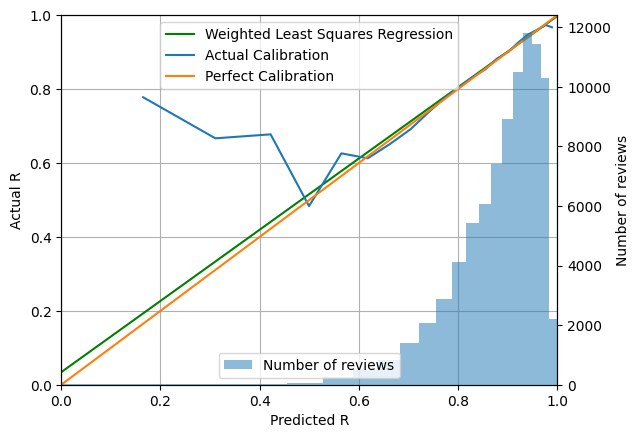

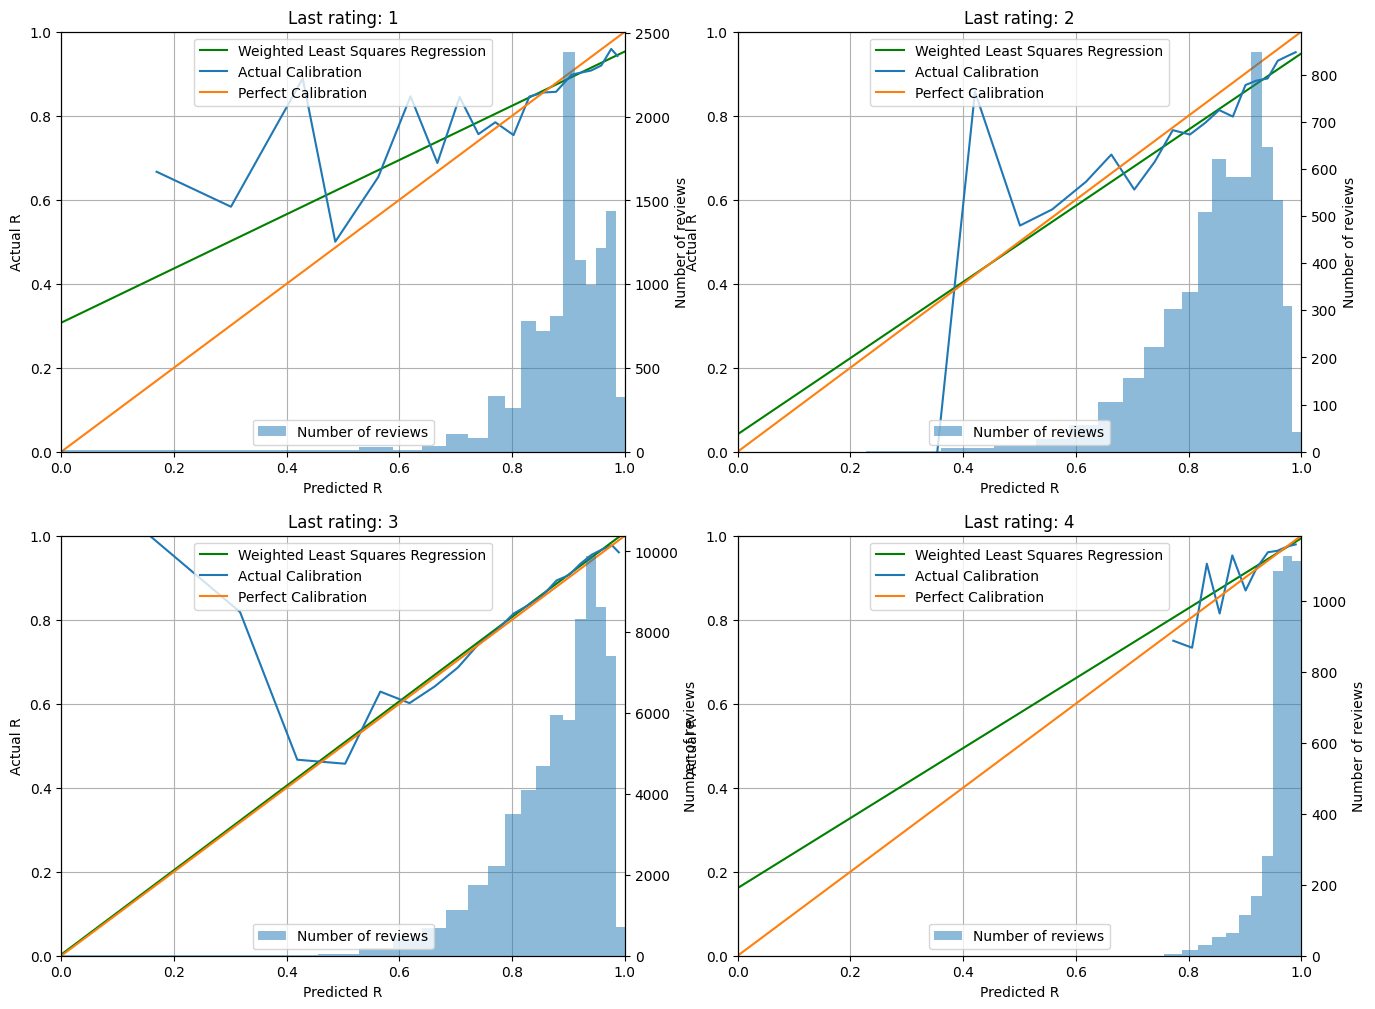

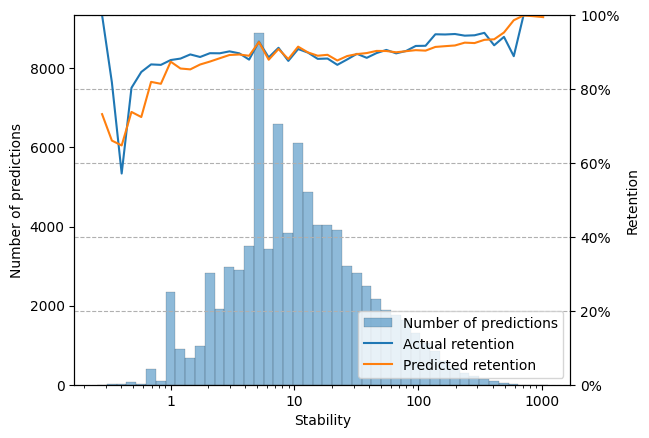

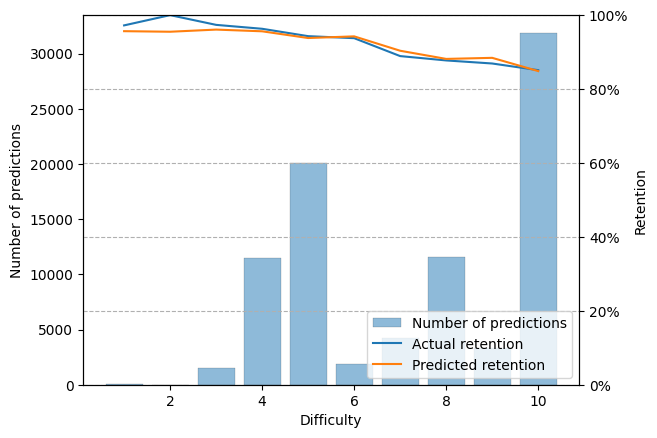

In [10]:
def calibration_graph(dataset):
    fig1 = plt.figure()
    metrics = plot_brier(
        dataset["p"], dataset["y"], bins=20, ax=fig1.add_subplot(111)
    )
    fig2 = plt.figure(figsize=(16, 12))
    for last_rating in ("1", "2", "3", "4"):
        calibration_data = dataset[dataset["r_history"].str.endswith(
            last_rating)]
        if calibration_data.empty:
            continue
        tqdm.write(f"\nLast rating: {last_rating}")
        plot_brier(
            calibration_data["p"],
            calibration_data["y"],
            bins=20,
            ax=fig2.add_subplot(2, 2, int(last_rating)),
            title=f"Last rating: {last_rating}",
        )
    fig3 = calibration_helper(
        dataset[["stability", "p", "y"]].copy(),
        "stability",
        lambda x: math.pow(1.2, math.floor(math.log(x, 1.2))),
        True,
    )
    fig4 = calibration_helper(
        dataset[["difficulty", "p", "y"]].copy(),
        "difficulty",
        lambda x: round(x),
        False,
    )
    return metrics, (fig1, fig2, fig3, fig4)

_, figs = calibration_graph(dataset)
for f in figs:
    f.show()

In [11]:
pls_dataset = dataset[
    (dataset["r_history"].str.endswith("1")) & (dataset["i"] > 2)
].copy()
my_collection = Collection(w)
pls_dataset["tensor"] = pls_dataset["tensor"].map(lambda x: x[:-1])
my_collection = Collection(w)
stabilities, difficulties = my_collection.batch_predict(pls_dataset)
pls_dataset["last_s"] = stabilities
pls_dataset["last_d"] = difficulties
pls_dataset["last_delta_t"] = pls_dataset["t_history"].map(
    lambda x: int(x.split(",")[-1])
)
pls_dataset["last_r"] = power_forgetting_curve(pls_dataset["delta_t"], pls_dataset["last_s"])
pls_dataset["last_s_bin"] = pls_dataset["last_s"].map(
    lambda x: math.pow(1.2, math.floor(math.log(x, 1.2)))
)
pls_dataset["last_d_bin"] = pls_dataset["last_d"].map(lambda x: round(x))
bins = 20
pls_dataset["last_r_bin"] = pls_dataset["last_r"].map(lambda x: (
        np.log(np.minimum(np.floor(np.exp(np.log(bins + 1) * x) - 1), bins - 1) + 1)
        / np.log(bins)
    ).round(3))

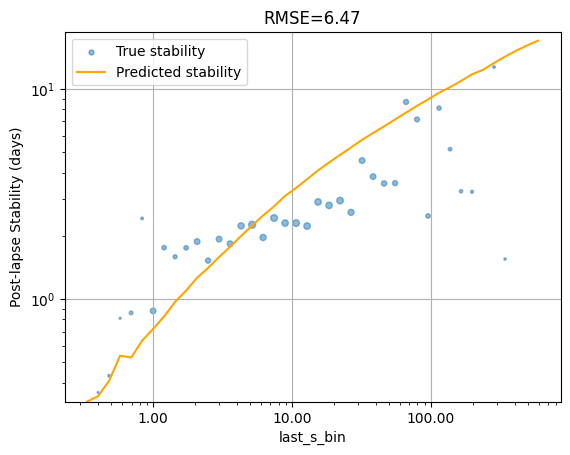

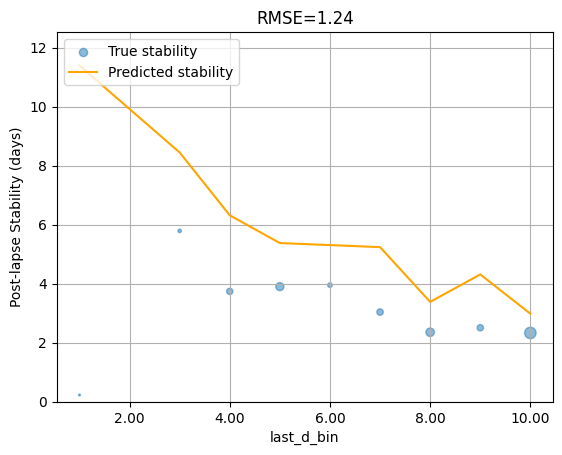

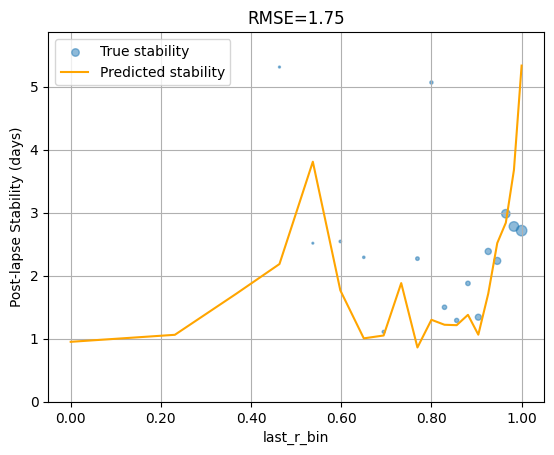

In [12]:
for group_key in ("last_s_bin", "last_d_bin", "last_r_bin"):

    pls_df_group = pls_dataset.groupby(
        by=["last_s_bin", "last_d_bin", "last_r_bin", "delta_t"], group_keys=False
    ).agg(
        {
            "y": ["mean", "count"],
            "p": "mean",
            "stability": "mean",
            "last_d": "mean",
        }
    )
    pls_df_group.reset_index(inplace=True)

    def cal_stability(tmp):
        delta_t = tmp["delta_t"]
        recall = tmp["y"]["mean"]
        count = tmp["y"]["count"]
        total_count = sum(count)

        def loss(stability):
            y_pred = power_forgetting_curve(delta_t, stability)
            logloss = sum(
                -(recall * np.log(y_pred) + (1 - recall) * np.log(1 - y_pred))
                * count
                / total_count
            )
            return logloss
        res = minimize(loss, 1, bounds=((0.1, 3650),))
        if res.success:
            tmp["true_s"] = res.x[0]
        else:
            tmp["true_s"] = np.nan
        tmp["predicted_s"] = np.average(tmp["stability"]["mean"], weights=count)
        tmp["total_count"] = total_count
        return tmp
    pls_df_group = (
        pls_df_group.groupby(by=[group_key], group_keys=False)
        .apply(cal_stability)
        .reset_index(drop=True)
    )
    pls_df_group.drop_duplicates(subset=[(group_key, "")], inplace=True)
    pls_df_group.sort_values(by=[group_key], inplace=True)
    rmse = mean_squared_error(pls_df_group["true_s"], pls_df_group["predicted_s"], sample_weight=pls_df_group["total_count"], squared=False)
    fig5 = plt.figure()
    ax1 = fig5.add_subplot(111)
    ax1.set_title(f'RMSE={rmse:.2f}')
    ax1.scatter(
        pls_df_group[group_key],
        pls_df_group["true_s"],
        s=np.sqrt(pls_df_group["total_count"]),
        label="True stability",
        alpha=0.5,
    )
    ax1.plot(
        pls_df_group[group_key],
        pls_df_group["predicted_s"],
        label="Predicted stability",
        color="orange",
    )
    ax1.set_ylim(0, pls_df_group["predicted_s"].max() * 1.1)
    ax1.legend(loc="upper left")
    ax1.set_xlabel(group_key)    
    if group_key == "last_s_bin":
        ax1.set_ylim(max(pls_df_group["predicted_s"].min(), 0.1), pls_df_group["predicted_s"].max() * 1.1)
        ax1.set_xscale("log")
        ax1.set_yscale("log")
    ax1.set_ylabel("Post-lapse Stability (days)")
    ax1.grid()
    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

In [13]:
ns_dataset = dataset[
    (dataset["r_history"].str.endswith("3")) & (dataset["i"] > 2)
].copy()
ns_dataset["tensor"] = ns_dataset["tensor"].map(lambda x: x[:-1])
my_collection = Collection(w)
stabilities, difficulties = my_collection.batch_predict(ns_dataset)
ns_dataset["last_s"] = stabilities
ns_dataset["last_d"] = difficulties
ns_dataset["last_delta_t"] = ns_dataset["t_history"].map(
    lambda x: int(x.split(",")[-1])
)
ns_dataset["last_r"] = power_forgetting_curve(ns_dataset["delta_t"], ns_dataset["last_s"])
ns_dataset["last_s_bin"] = ns_dataset["last_s"].map(
    lambda x: math.pow(1.2, math.floor(math.log(x, 1.2)))
)
ns_dataset["last_d_bin"] = ns_dataset["last_d"].map(lambda x: round(x))
bins = 20
ns_dataset["last_r_bin"] = ns_dataset["last_r"].map(lambda x: (
        np.log(np.minimum(np.floor(np.exp(np.log(bins + 1) * x) - 1), bins - 1) + 1)
        / np.log(bins)
    ).round(3))

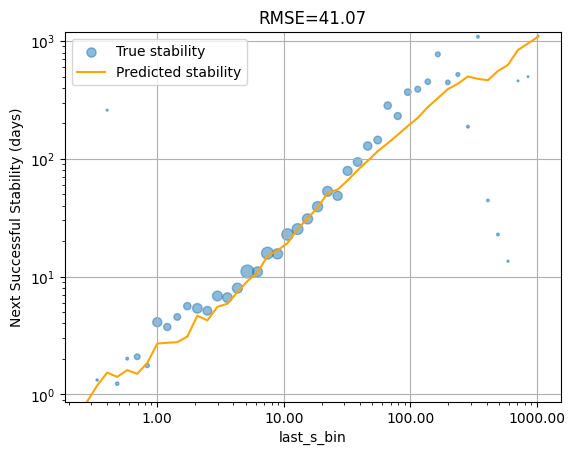

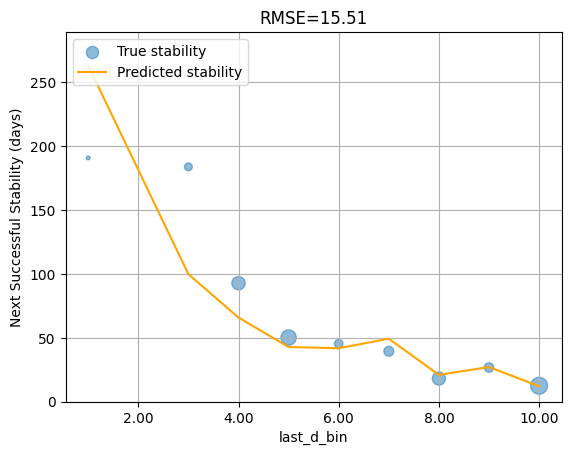

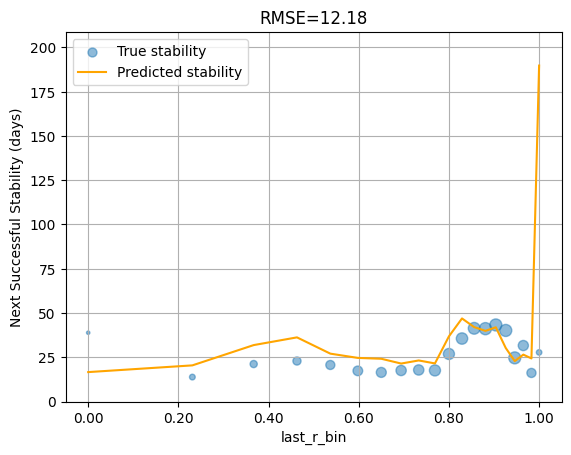

In [14]:
for group_key in ("last_s_bin", "last_d_bin", "last_r_bin"):
    ns_df_group = ns_dataset.groupby(
        by=["last_s_bin", "last_d_bin", "last_r_bin", "delta_t"], group_keys=False
    ).agg(
        {
            "y": ["mean", "count"],
            "p": "mean",
            "stability": "mean",
            "last_d": "mean",
        }
    )
    ns_df_group.reset_index(inplace=True)

    def cal_stability(tmp):
        delta_t = tmp["delta_t"]
        recall = tmp["y"]["mean"]
        count = tmp["y"]["count"]
        total_count = sum(count)

        def loss(stability):
            y_pred = power_forgetting_curve(delta_t, stability)
            logloss = sum(
                -(recall * np.log(y_pred) + (1 - recall) * np.log(1 - y_pred))
                * count
                / total_count
            )
            return logloss
        res = minimize(loss, 1, bounds=((0.1, 3650),))
        if res.success:
            tmp["true_s"] = res.x[0]
        else:
            tmp["true_s"] = np.nan
        tmp["predicted_s"] = np.average(tmp["stability"]["mean"], weights=count)
        tmp["total_count"] = total_count
        return tmp
    ns_df_group = (
        ns_df_group.groupby(by=[group_key], group_keys=False)
        .apply(cal_stability)
        .reset_index(drop=True)
    )
    ns_df_group.drop_duplicates(subset=[(group_key, "")], inplace=True)
    ns_df_group.sort_values(by=[group_key], inplace=True)
    rmse = mean_squared_error(ns_df_group["true_s"], ns_df_group["predicted_s"], sample_weight=ns_df_group["total_count"], squared=False)
    fig5 = plt.figure()
    ax1 = fig5.add_subplot(111)
    ax1.set_title(f'RMSE={rmse:.2f}')
    ax1.scatter(
        ns_df_group[group_key],
        ns_df_group["true_s"],
        s=np.sqrt(ns_df_group["total_count"]),
        label="True stability",
        alpha=0.5,
    )
    ax1.plot(
        ns_df_group[group_key],
        ns_df_group["predicted_s"],
        label="Predicted stability",
        color="orange",
    )
    ax1.set_ylim(0, ns_df_group["predicted_s"].max() * 1.1)
    ax1.legend(loc="upper left")
    ax1.set_xlabel(group_key)
    if group_key == "last_s_bin":
        ax1.set_ylim(max(ns_df_group["predicted_s"].min(), 0.1), ns_df_group["predicted_s"].max() * 1.1)
        ax1.set_xscale("log")
        ax1.set_yscale("log")
    ax1.set_ylabel("Next Successful Stability (days)")
    ax1.grid()
    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

### 4.3 Cumulative B-W Metric

For details about Cumulative B-W Metric, please see: [Algorithm SM-17 as a good predictor - supermemo.guru](https://supermemo.guru/wiki/Universal_metric_for_cross-comparison_of_spaced_repetition_algorithms#Algorithm_SM-17_as_a_good_predictor)

In [15]:
def bw_matrix():
    B_W_Metric_raw = dataset[["difficulty", "stability", "p", "y"]].copy()
    B_W_Metric_raw["s_bin"] = B_W_Metric_raw["stability"].map(
        lambda x: round(math.pow(1.4, math.floor(math.log(x, 1.4))), 2)
    )
    B_W_Metric_raw["d_bin"] = B_W_Metric_raw["difficulty"].map(
        lambda x: int(round(x))
    )
    B_W_Metric = (
        B_W_Metric_raw.groupby(by=["s_bin", "d_bin"]).agg("mean").reset_index()
    )
    B_W_Metric_count = (
        B_W_Metric_raw.groupby(by=["s_bin", "d_bin"]).agg(
            "count").reset_index()
    )
    B_W_Metric["B-W"] = B_W_Metric["p"] - B_W_Metric["y"]
    n = len(dataset)
    bins = len(B_W_Metric)
    B_W_Metric_pivot = B_W_Metric[
        B_W_Metric_count["p"] > max(50, n / (3 * bins))
    ].pivot(index="s_bin", columns="d_bin", values="B-W")
    return (
        B_W_Metric_pivot.apply(pd.to_numeric)
        .style.background_gradient(cmap="seismic", axis=None, vmin=-0.2, vmax=0.2)
        .format("{:.2%}", na_rep="")
    )


bw_matrix()

d_bin,3,4,5,6,7,8,9,10
s_bin,,,,,,,,
0.510000,,,,,,,,-5.91%
0.710000,,,,,,,,-5.91%
1.000000,,,,,-0.05%,0.03%,,-3.57%
1.400000,,,,,,,,-2.89%
1.960000,,,,,,-3.61%,,-1.65%
2.740000,,,,,,0.16%,,-0.98%
3.840000,,,,,,-0.02%,2.60%,0.59%
5.380000,,,-0.01%,-0.11%,-0.47%,-1.77%,-0.58%,-0.28%
7.530000,,,-1.79%,1.85%,1.97%,2.16%,2.26%,0.56%


### 4.4 Compare with SM-2

For details about universal metric, please see: [Algorithmic contest: SuperMemo 2 vs. SuperMemo 17 - supermemo.guru](https://supermemo.guru/wiki/Universal_metric_for_cross-comparison_of_spaced_repetition_algorithms#Algorithmic_contest:_SuperMemo_2_vs._SuperMemo_17)

Loss of SM-2: 0.3842
R-squared: -6.8749
RMSE: 0.1436
MAE: 0.0803
[0.67854309 0.26345247]
Universal Metric of FSRS: 0.0098
Universal Metric of SM2: 0.0706


(<Figure size 640x480 with 2 Axes>, <Figure size 600x600 with 1 Axes>)

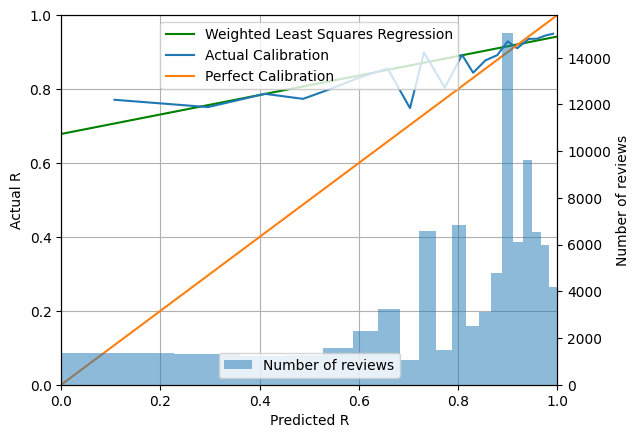

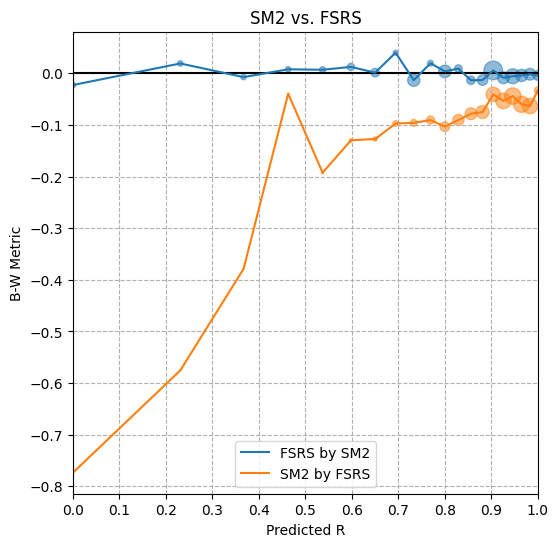

In [16]:
def sm2(history):
    ivl = 0
    ef = 2.5
    reps = 0
    for delta_t, rating in history:
        delta_t = delta_t.item()
        rating = rating.item() + 1
        if rating > 2:
            if reps == 0:
                ivl = 1
                reps = 1
            elif reps == 1:
                ivl = 6
                reps = 2
            else:
                ivl = ivl * ef
                reps += 1
        else:
            ivl = 1
            reps = 0
        ef = max(1.3, ef + (0.1 - (5 - rating) * (0.08 + (5 - rating) * 0.02)))
        ivl = max(1, round(ivl + 0.01))
    return ivl


dataset["sm2_ivl"] = dataset["tensor"].map(sm2)
dataset["sm2_p"] = np.exp(np.log(0.9) * dataset["delta_t"] / dataset["sm2_ivl"])
dataset["log_loss"] = dataset.apply(
    lambda row: -np.log(row["sm2_p"]) if row["y"] == 1 else -np.log(1 - row["sm2_p"]),
    axis=1,
)
tqdm.write(f"Loss of SM-2: {dataset['log_loss'].mean():.4f}")
cross_comparison = dataset[["sm2_p", "p", "y"]].copy()
fig1 = plt.figure()
plot_brier(
    cross_comparison["sm2_p"],
    cross_comparison["y"],
    bins=20,
    ax=fig1.add_subplot(111),
)
fig2 = plt.figure(figsize=(6, 6))
ax = fig2.gca()


def get_bin(x, bins=20):
    return (
        np.log(np.minimum(np.floor(np.exp(np.log(bins + 1) * x) - 1), bins - 1) + 1)
        / np.log(bins)
    ).round(3)


cross_comparison["SM2_B-W"] = cross_comparison["sm2_p"] - cross_comparison["y"]
cross_comparison["SM2_bin"] = cross_comparison["sm2_p"].map(get_bin)
cross_comparison["FSRS_B-W"] = cross_comparison["p"] - cross_comparison["y"]
cross_comparison["FSRS_bin"] = cross_comparison["p"].map(get_bin)
ax.axhline(y=0.0, color="black", linestyle="-")
cross_comparison_group = cross_comparison.groupby(by="SM2_bin").agg(
    {"y": ["mean"], "FSRS_B-W": ["mean"], "p": ["mean", "count"]}
)
tqdm.write(
    f"Universal Metric of FSRS: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group['p', 'mean'], sample_weight=cross_comparison_group['p', 'count'], squared=False):.4f}"
)
cross_comparison_group["p", "percent"] = (
    cross_comparison_group["p", "count"] / cross_comparison_group["p", "count"].sum()
)
ax.scatter(
    cross_comparison_group.index,
    cross_comparison_group["FSRS_B-W", "mean"],
    s=cross_comparison_group["p", "percent"] * 1024,
    alpha=0.5,
)
ax.plot(cross_comparison_group["FSRS_B-W", "mean"], label="FSRS by SM2")
cross_comparison_group = cross_comparison.groupby(by="FSRS_bin").agg(
    {"y": ["mean"], "SM2_B-W": ["mean"], "sm2_p": ["mean", "count"]}
)
tqdm.write(
    f"Universal Metric of SM2: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group['sm2_p', 'mean'], sample_weight=cross_comparison_group['sm2_p', 'count'], squared=False):.4f}"
)
cross_comparison_group["sm2_p", "percent"] = (
    cross_comparison_group["sm2_p", "count"]
    / cross_comparison_group["sm2_p", "count"].sum()
)
ax.scatter(
    cross_comparison_group.index,
    cross_comparison_group["SM2_B-W", "mean"],
    s=cross_comparison_group["sm2_p", "percent"] * 1024,
    alpha=0.5,
)
ax.plot(cross_comparison_group["SM2_B-W", "mean"], label="SM2 by FSRS")
ax.legend(loc="lower center")
ax.grid(linestyle="--")
ax.set_title("SM2 vs. FSRS")
ax.set_xlabel("Predicted R")
ax.set_ylabel("B-W Metric")
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
fig1, fig2